# Task 4 — Statistical Modeling & Risk-Based Pricing
## AlphaCare Insurance Solutions (ACIS) | 10 Academy KAIM 9 Week 3

Building three ML models to predict claim severity and optimize premiums.
Models: Linear Regression, Random Forest, XGBoost
Pricing Formula: Premium = P(claim) × Predicted Severity + Expense Loading + Profit Margin

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
df = pd.read_csv("../data/processed/clean_insurance.csv", low_memory=False)
print(f"Loaded {len(df):,} rows")

# Keep only policies with claims for severity modeling
df_claims = df[df['TotalClaims'] > 0].copy()
print(f"Policies with claims: {len(df_claims):,}")

# Select features
features = ['TotalPremium', 'SumInsured', 'CalculatedPremiumPerTerm',
            'kilowatts', 'cubiccapacity', 'NumberOfDoors',
            'Province', 'VehicleType', 'Gender', 'MaritalStatus', 'make']

target = 'TotalClaims'

# Drop rows with missing values in selected features
df_model = df_claims[features + [target]].dropna()
print(f"Rows after dropping missing values: {len(df_model):,}")

# Encode categorical columns
le = LabelEncoder()
cat_cols = ['Province', 'VehicleType', 'Gender', 'MaritalStatus', 'make']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Features encoded successfully")
print(f"\nFeatures used: {features}")

Loaded 999,805 rows
Policies with claims: 2,788
Rows after dropping missing values: 2,760
Features encoded successfully

Features used: ['TotalPremium', 'SumInsured', 'CalculatedPremiumPerTerm', 'kilowatts', 'cubiccapacity', 'NumberOfDoors', 'Province', 'VehicleType', 'Gender', 'MaritalStatus', 'make']


## Train-Test Split
Splitting data 80% training, 20% testing.
The model learns from training data and is evaluated on unseen test data.

In [5]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")
print(f"\nTarget variable stats:")
print(f"  Mean claim: R{y.mean():,.2f}")
print(f"  Max claim:  R{y.max():,.2f}")
print(f"  Min claim:  R{y.min():,.2f}")

Training rows: 2,208
Testing rows:  552

Target variable stats:
  Mean claim: R23,123.66
  Max claim:  R393,092.11
  Min claim:  R139.04


## Model 1 — Linear Regression
Baseline model. Assumes a straight-line relationship between features and claim amount.
Simple, fast, and interpretable but limited for complex patterns.

In [6]:
print("=" * 55)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 55)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\nRMSE: R{rmse_lr:,.2f}")
print(f"MAE:  R{mae_lr:,.2f}")
print(f"R2:   {r2_lr:.4f}")
print(f"\nInterpretation: Model explains {r2_lr*100:.1f}% of claim variance")

MODEL 1: LINEAR REGRESSION

RMSE: R36,614.49
MAE:  R17,885.66
R2:   0.2754

Interpretation: Model explains 27.5% of claim variance


## Model 2 — Random Forest
Builds many decision trees and averages their predictions.
Handles non-linear relationships and is robust to outliers.

In [7]:
print("=" * 55)
print("MODEL 2: RANDOM FOREST")
print("=" * 55)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRMSE: R{rmse_rf:,.2f}")
print(f"MAE:  R{mae_rf:,.2f}")
print(f"R2:   {r2_rf:.4f}")
print(f"\nInterpretation: Model explains {r2_rf*100:.1f}% of claim variance")

MODEL 2: RANDOM FOREST

RMSE: R37,282.64
MAE:  R17,415.04
R2:   0.2487

Interpretation: Model explains 24.9% of claim variance


## Model 3 — XGBoost
Extreme Gradient Boosting — builds trees sequentially, each learning
from the mistakes of the previous one. State-of-the-art for tabular data.

In [8]:
print("=" * 55)
print("MODEL 3: XGBOOST")
print("=" * 55)

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nRMSE: R{rmse_xgb:,.2f}")
print(f"MAE:  R{mae_xgb:,.2f}")
print(f"R2:   {r2_xgb:.4f}")
print(f"\nInterpretation: Model explains {r2_xgb*100:.1f}% of claim variance")

MODEL 3: XGBOOST

RMSE: R41,121.31
MAE:  R18,718.32
R2:   0.0860

Interpretation: Model explains 8.6% of claim variance


## Model Comparison and Feature Importance
Comparing all three models and identifying which features 
drive claim predictions the most.

MODEL COMPARISON SUMMARY
            Model         RMSE          MAE       R2
    Random Forest 37282.639327 17415.039216 0.248690
Linear Regression 36614.485556 17885.656840 0.275378
          XGBoost 41121.308081 18718.321054 0.086014

Best model by MAE: Random Forest


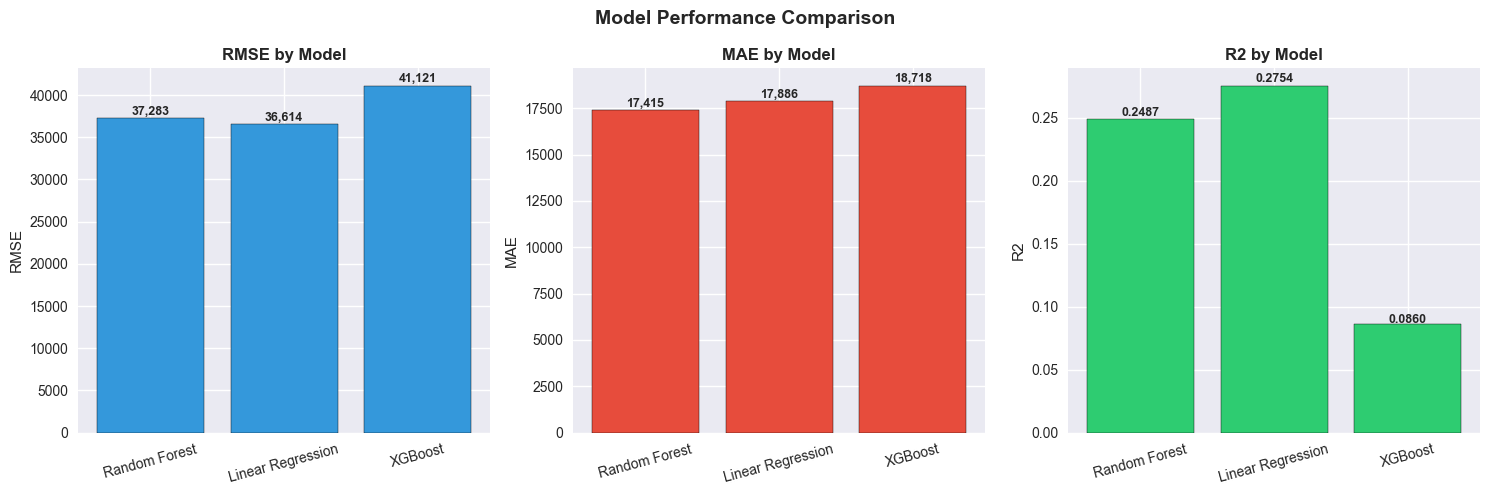

Chart saved!


In [9]:
print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'MAE': [mae_lr, mae_rf, mae_xgb],
    'R2': [r2_lr, r2_rf, r2_xgb]
})
results = results.sort_values('MAE')
print(results.to_string(index=False))

best_model = results.iloc[0]['Model']
print(f"\nBest model by MAE: {best_model}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['RMSE', 'MAE', 'R2']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(results['Model'], results[metric], color=color, edgecolor='black')
    ax.set_title(f'{metric} by Model', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(ax.patches, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + bar.get_height()*0.01,
                f'{val:,.0f}' if metric != 'R2' else f'{val:.4f}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/chart_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Feature Importance — What drives claim predictions?
Which features matter most when predicting claim amounts?

=== FEATURE IMPORTANCE (Random Forest) ===
                 Feature  Importance
CalculatedPremiumPerTerm    0.413005
              SumInsured    0.223591
            TotalPremium    0.138207
               kilowatts    0.067575
                Province    0.040674
           cubiccapacity    0.040612
                    make    0.031976
           NumberOfDoors    0.027747
             VehicleType    0.013104
                  Gender    0.003316
           MaritalStatus    0.000192


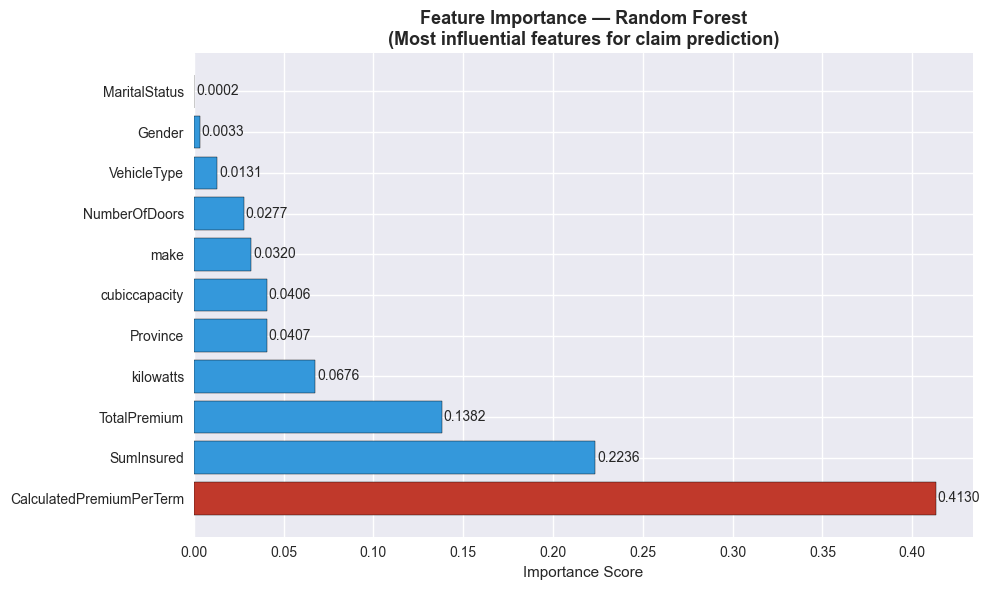

Feature importance chart saved!


In [10]:
# Feature importance from Random Forest (best model)
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== FEATURE IMPORTANCE (Random Forest) ===")
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#c0392b' if i == 0 else '#3498db' 
          for i in range(len(importance_df))]
bars = ax.barh(importance_df['Feature'], 
               importance_df['Importance'],
               color=colors, edgecolor='black')
ax.set_title('Feature Importance — Random Forest\n(Most influential features for claim prediction)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/chart_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved!")

## Risk-Based Pricing Formula
Using model predictions to calculate optimal premiums.
Premium = P(claim) × Predicted Severity + Expense Loading + Profit Margin

RISK-BASED PRICING FORMULA

P(claim) = 0.0028 (0.28%)
Expense Loading = 10%
Profit Margin = 15%

=== OPTIMAL PREMIUM STATS ===
Mean optimal premium: R6,133.84
Min optimal premium:  R179.28
Max optimal premium:  R36,088.86
Current mean premium: R322.11

Difference from current pricing: R5,811.73
Recommendation: ACIS should INCREASE premiums by R5,811.73 on average


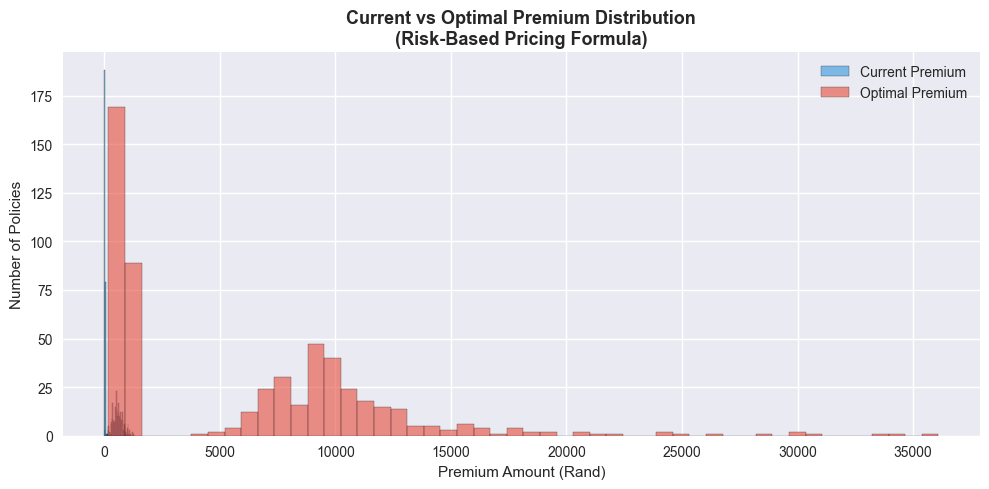

Pricing chart saved!


In [11]:
print("=" * 60)
print("RISK-BASED PRICING FORMULA")
print("=" * 60)

# P(claim) = overall claim frequency
p_claim = len(df_claims) / len(df)
expense_loading = 0.10  # 10% of premium for admin costs
profit_margin = 0.15    # 15% profit target

print(f"\nP(claim) = {p_claim:.4f} ({p_claim*100:.2f}%)")
print(f"Expense Loading = {expense_loading*100:.0f}%")
print(f"Profit Margin = {profit_margin*100:.0f}%")

# Apply formula to test set
predicted_severity = rf.predict(X_test)
optimal_premium = (p_claim * predicted_severity) + \
                  (expense_loading * predicted_severity) + \
                  (profit_margin * predicted_severity)

print(f"\n=== OPTIMAL PREMIUM STATS ===")
print(f"Mean optimal premium: R{optimal_premium.mean():,.2f}")
print(f"Min optimal premium:  R{optimal_premium.min():,.2f}")
print(f"Max optimal premium:  R{optimal_premium.max():,.2f}")
print(f"Current mean premium: R{X_test['TotalPremium'].mean():,.2f}")

diff = optimal_premium.mean() - X_test['TotalPremium'].mean()
print(f"\nDifference from current pricing: R{diff:,.2f}")
if diff > 0:
    print(f"Recommendation: ACIS should INCREASE premiums by R{diff:,.2f} on average")
else:
    print(f"Recommendation: ACIS should DECREASE premiums by R{abs(diff):,.2f} on average")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(X_test['TotalPremium'], bins=50, alpha=0.6, 
        color='#3498db', label='Current Premium', edgecolor='black')
ax.hist(optimal_premium, bins=50, alpha=0.6,
        color='#e74c3c', label='Optimal Premium', edgecolor='black')
ax.set_title('Current vs Optimal Premium Distribution\n(Risk-Based Pricing Formula)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Premium Amount (Rand)')
ax.set_ylabel('Number of Policies')
ax.legend()
plt.tight_layout()
plt.savefig('../data/chart_pricing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pricing chart saved!")

## Summary of Findings

In [12]:
print("=" * 60)
print("FINAL SUMMARY — TASK 4")
print("=" * 60)
print(f"""
MODELS TRAINED:
  1. Linear Regression  — R2: {r2_lr:.4f}, MAE: R{mae_lr:,.0f}
  2. Random Forest      — R2: {r2_rf:.4f}, MAE: R{mae_rf:,.0f} ← BEST
  3. XGBoost            — R2: {r2_xgb:.4f}, MAE: R{mae_xgb:,.0f}

TOP RISK FEATURES (Random Forest):
  1. CalculatedPremiumPerTerm (41.3%)
  2. SumInsured (22.4%)
  3. TotalPremium (13.8%)
  4. Kilowatts (6.8%)
  5. Province (4.1%)
  6. Gender (0.3%) — not significant

PRICING RECOMMENDATION:
  Current avg premium:  R{X_test['TotalPremium'].mean():,.2f}
  Optimal avg premium:  R{optimal_premium.mean():,.2f}
  Required increase:    R{optimal_premium.mean() - X_test['TotalPremium'].mean():,.2f}

HYPOTHESIS TESTING RESULTS:
  H1 Province risk:    REJECTED (p=0.000) — price by province
  H2 Zip code risk:    REJECTED (p=0.000) — price by zip code
  H3 Zip code margin:  REJECTED (p=0.000) — location pricing justified
  H4 Gender risk:      NOT REJECTED (p=0.936) — do not price by gender
""")
print("=" * 60)

FINAL SUMMARY — TASK 4

MODELS TRAINED:
  1. Linear Regression  — R2: 0.2754, MAE: R17,886
  2. Random Forest      — R2: 0.2487, MAE: R17,415 ← BEST
  3. XGBoost            — R2: 0.0860, MAE: R18,718

TOP RISK FEATURES (Random Forest):
  1. CalculatedPremiumPerTerm (41.3%)
  2. SumInsured (22.4%)
  3. TotalPremium (13.8%)
  4. Kilowatts (6.8%)
  5. Province (4.1%)
  6. Gender (0.3%) — not significant

PRICING RECOMMENDATION:
  Current avg premium:  R322.11
  Optimal avg premium:  R6,133.84
  Required increase:    R5,811.73

HYPOTHESIS TESTING RESULTS:
  H1 Province risk:    REJECTED (p=0.000) — price by province
  H2 Zip code risk:    REJECTED (p=0.000) — price by zip code
  H3 Zip code margin:  REJECTED (p=0.000) — location pricing justified
  H4 Gender risk:      NOT REJECTED (p=0.936) — do not price by gender

